# 21CSE453T Speech Recognition — Activity Unit 3
## From Voice to Text and Back: ASR and TTS on Disfluent (Stuttered) Speech

**Pipeline followed:**

`Speech → Feature Extraction → Log-Mel Spectrum → ASR → CTC → Text → TTS → Speech`

**Input:** `campus-voice-kore.wav`, about 46 s of one speaker who is panicking and asking for directions. The speech has
*temporary disruptions in the normal vocal pattern*: silent **blocks** in the middle of phrases, **word/phrase repetitions**
("I'm… I'm", "is it… is it") and broken-off phrases ("and I— oh").

| Section | Deliverable |
|---|---|
| 1 | Waveform |
| 2 | Feature extraction, step by step → log-Mel spectrogram (+ MFCC) |
| 3 | Disfluency (stammer) analysis |
| 4 | ASR architecture diagram |
| 5 | ASR with 4 models |
| 6 | CTC explanation + posteriorgram, collapse rule, CTC loss, forced alignment |
| 7 | WER calculation (own dynamic-programming code, checked against `jiwer`) |
| 8 | ASR comparison table |
| 9 | TTS output + round-trip (TTS → ASR) |

In [2]:
# Colab: !pip install librosa jiwer soundfile transformers pyttsx3 gTTS
import os, time, re, warnings
os.environ["HF_HUB_DISABLE_IMPLICIT_TOKEN"] = "1"   # public models only, no token needed
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, torch, librosa, librosa.display, soundfile as sf, jiwer
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from transformers import (Wav2Vec2Processor, Wav2Vec2ForCTC,
                          WhisperProcessor, WhisperForConditionalGeneration)
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

AUDIO = "campus-voice-kore.wav"
OUT = "outputs"; os.makedirs(OUT, exist_ok=True)
SR = 16000                       # all ASR models expect 16 kHz
pd.set_option("display.max_colwidth", 120)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
torch.manual_seed(0)

## 1. Speech input — waveform
The file is recorded at 24 kHz, 16-bit mono. We resample it to **16 kHz**, which the ASR models were trained on.
Long flat stretches in the waveform are the **silent blocks**: the speaker gets stuck in the middle of a phrase.

Original: 24000 Hz, 1 ch, PCM_16, 46.04 s
Resampled: 16000 Hz, 736640 samples, peak=0.892, RMS=0.1497


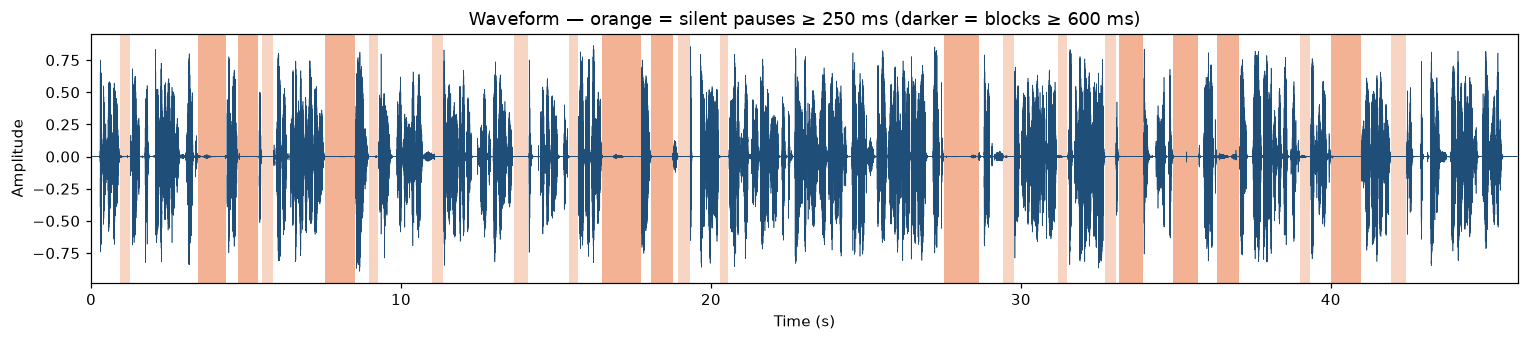

In [3]:
info = sf.info(AUDIO)
print(f"Original: {info.samplerate} Hz, {info.channels} ch, {info.subtype}, {info.duration:.2f} s")
y, _ = librosa.load(AUDIO, sr=SR)
t = np.arange(len(y)) / SR
dur = len(y) / SR
print(f"Resampled: {SR} Hz, {len(y)} samples, peak={np.abs(y).max():.3f}, RMS={np.sqrt(np.mean(y**2)):.4f}")
display(Audio(y, rate=SR))

# speech / silence segmentation (energy based, 35 dB below peak)
intervals = librosa.effects.split(y, top_db=35, frame_length=1024, hop_length=256)
gaps = [(intervals[i][1]/SR, intervals[i+1][0]/SR) for i in range(len(intervals)-1)]
pauses = [(a, b) for a, b in gaps if b - a >= 0.25]

fig, ax = plt.subplots(figsize=(14, 3.2))
ax.plot(t, y, lw=0.4, color="#1f4e79")
for a, b in pauses:
    ax.axvspan(a, b, color="#e8743b", alpha=0.30 if b-a < 0.6 else 0.55, lw=0)
ax.set(xlim=(0, dur), xlabel="Time (s)", ylabel="Amplitude",
       title="Waveform — orange = silent pauses ≥ 250 ms (darker = blocks ≥ 600 ms)")
plt.tight_layout(); plt.savefig(f"{OUT}/01_waveform.png", dpi=150); plt.show()

## 2. Feature extraction → log-Mel spectrum
How a log-Mel spectrogram is computed:

1. **Pre-emphasis**: $y[n] = x[n] - 0.97\,x[n-1]$ boosts the high frequencies.
2. **Framing**: 25 ms windows (400 samples) with a 10 ms hop (160 samples). Speech is roughly stationary over this span.
3. **Windowing**: a Hamming window reduces spectral leakage.
4. **FFT → power spectrum**: $P = |FFT_{512}(frame)|^2 / N$
5. **Mel filterbank**: 80 triangular filters spaced on the Mel scale, $m = 2595\log_{10}(1+f/700)$, which mimics how the cochlea resolves pitch.
6. **Log compression**: $10\log_{10}(\cdot)$ dB, which mimics how we perceive loudness.

The first block below does every step by hand for one frame. The second computes the full spectrogram (and MFCC = DCT of log-Mel).

frames: (4605, 400) | power spectrum: (4605, 257) | log-Mel: (4605, 80)


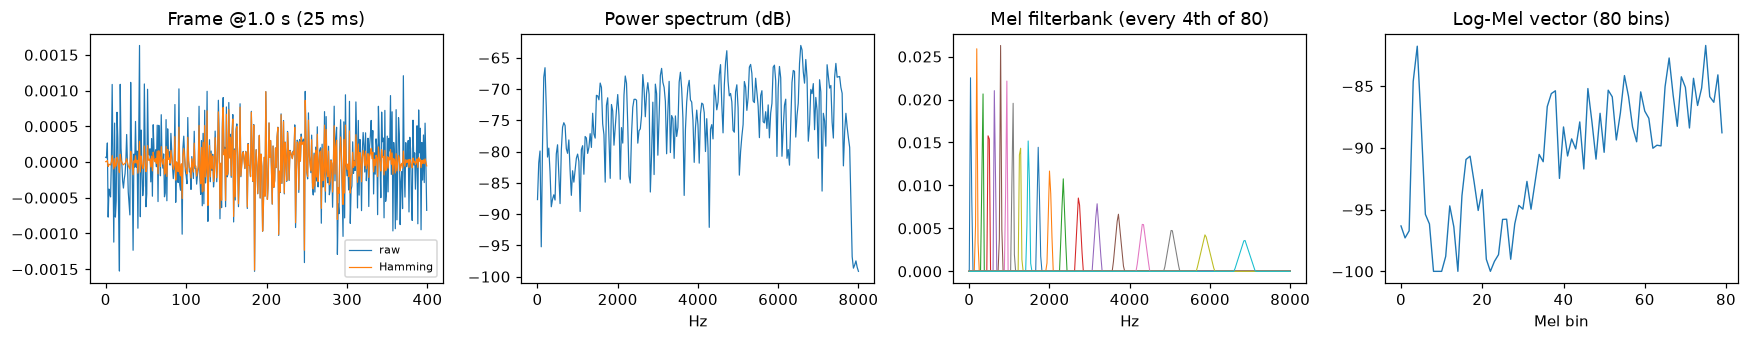

In [4]:
N_FFT, WIN, HOP, N_MELS = 512, 400, 160, 80
x = np.append(y[0], y[1:] - 0.97 * y[:-1])                              # 1 pre-emphasis
frames = librosa.util.frame(np.pad(x, (0, WIN)), frame_length=WIN, hop_length=HOP).T   # 2 framing
win = np.hamming(WIN)                                                    # 3 window
power = np.abs(np.fft.rfft(frames * win, n=N_FFT)) ** 2 / N_FFT          # 4 power spectrum
mel_fb = librosa.filters.mel(sr=SR, n_fft=N_FFT, n_mels=N_MELS, fmin=0, fmax=SR/2)   # 5 filterbank
mel_manual = power @ mel_fb.T
logmel_manual = 10 * np.log10(np.maximum(mel_manual, 1e-10))             # 6 log
print("frames:", frames.shape, "| power spectrum:", power.shape, "| log-Mel:", logmel_manual.shape)

k = int(1.0 * SR / HOP)           # a voiced frame at t = 1.0 s ("excuse")
freqs = np.fft.rfftfreq(N_FFT, 1/SR)
fig, axs = plt.subplots(1, 4, figsize=(16, 3.2))
axs[0].plot(frames[k], lw=.8, label="raw"); axs[0].plot(frames[k]*win, lw=.8, label="Hamming"); axs[0].legend(fontsize=7)
axs[0].set_title("Frame @1.0 s (25 ms)")
axs[1].plot(freqs, 10*np.log10(power[k]+1e-10), lw=.8); axs[1].set_title("Power spectrum (dB)"); axs[1].set_xlabel("Hz")
for f in mel_fb[::4]: axs[2].plot(freqs, f, lw=.7)
axs[2].set_title("Mel filterbank (every 4th of 80)"); axs[2].set_xlabel("Hz")
axs[3].plot(logmel_manual[k], lw=.9); axs[3].set_title("Log-Mel vector (80 bins)"); axs[3].set_xlabel("Mel bin")
plt.tight_layout(); plt.savefig(f"{OUT}/02_feature_steps.png", dpi=150); plt.show()

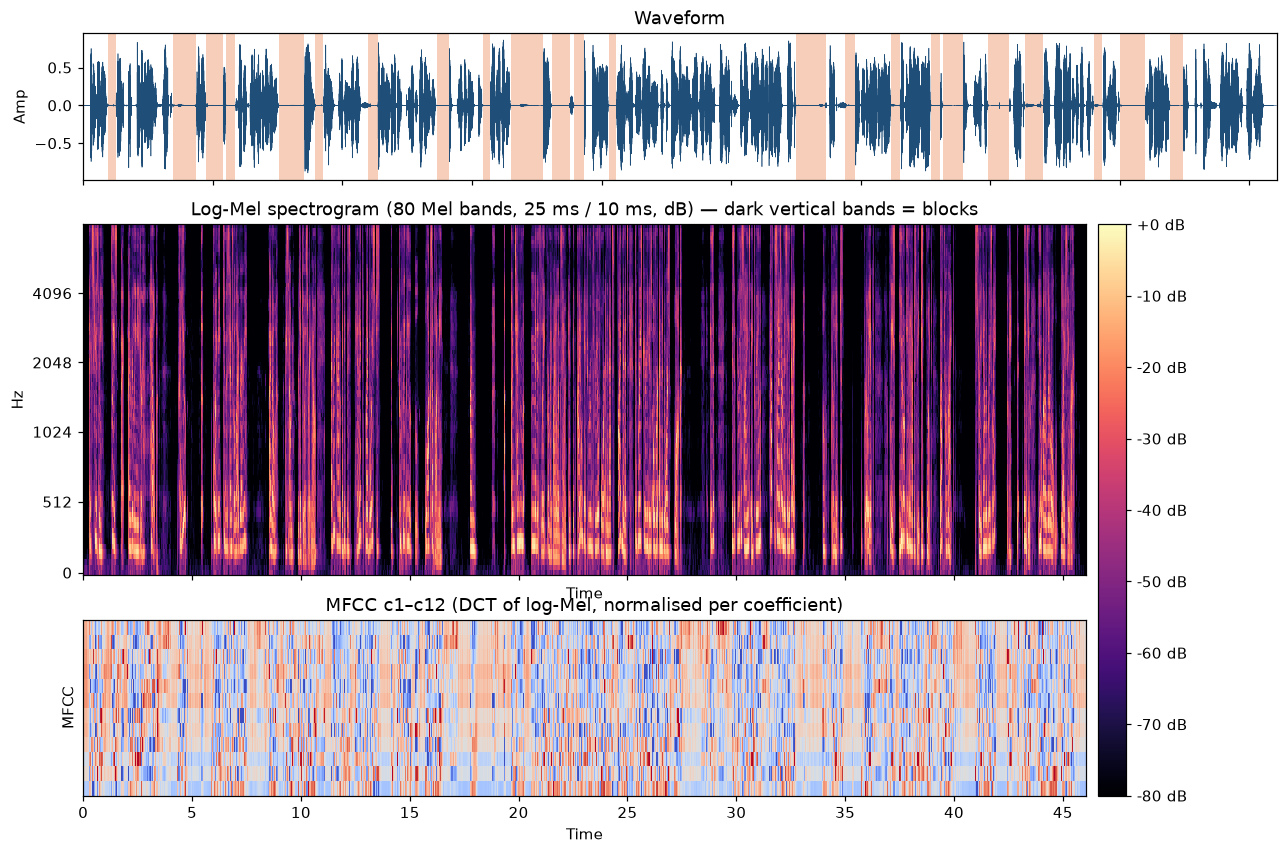

log-Mel shape (mel bands x frames): (80, 4605) | MFCC shape: (13, 4605)


In [5]:
S = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT, win_length=WIN, hop_length=HOP,
                                   n_mels=N_MELS, window="hamming", power=2.0)
logmel = librosa.power_to_db(S, ref=np.max)
mfcc = librosa.feature.mfcc(S=librosa.power_to_db(S), n_mfcc=13)

fig, axs = plt.subplots(3, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [1, 2.4, 1.2]})
axs[0].plot(t, y, lw=.4, color="#1f4e79"); axs[0].set_ylabel("Amp"); axs[0].set_title("Waveform")
for a, b in pauses: axs[0].axvspan(a, b, color="#e8743b", alpha=.35, lw=0)
img = librosa.display.specshow(logmel, sr=SR, hop_length=HOP, x_axis="time", y_axis="mel", ax=axs[1], cmap="magma")
axs[1].set_title("Log-Mel spectrogram (80 Mel bands, 25 ms / 10 ms, dB) — dark vertical bands = blocks")
fig.colorbar(img, ax=axs[1:], format="%+2.0f dB", pad=.01)
mfcc_n = (mfcc[1:] - mfcc[1:].mean(1, keepdims=True)) / mfcc[1:].std(1, keepdims=True)   # c1..c12, per-coefficient z-score
librosa.display.specshow(mfcc_n, sr=SR, hop_length=HOP, x_axis="time", ax=axs[2], cmap="coolwarm", vmin=-2.5, vmax=2.5)
axs[2].set_title("MFCC c1–c12 (DCT of log-Mel, normalised per coefficient)"); axs[2].set_ylabel("MFCC")
plt.savefig(f"{OUT}/03_logmel_spectrogram.png", dpi=150, bbox_inches="tight"); plt.show()
print("log-Mel shape (mel bands x frames):", logmel.shape, "| MFCC shape:", mfcc.shape)

## 3. Disfluency analysis — where the vocal pattern is disrupted
Fluent read speech usually has inter-word pauses under about 250 ms. Here we measure every silent gap, then label it:
- **Block**: ≥ 600 ms of silence *inside* a phrase. The speaker is stuck ("completely … locks up", "I'm … I'm").
- **Pause**: 250–600 ms.

Speaking rate and the share of time spent silent are compared with typical fluent speech.

In [6]:
pause_df = pd.DataFrame([(a, b, b-a) for a, b in pauses], columns=["start_s", "end_s", "dur_s"]).round(2)
pause_df["type"] = np.where(pause_df.dur_s >= 0.6, "BLOCK (>=600 ms)", "pause")
speech_time = sum((e-s) for s, e in intervals) / SR
silence_ratio = 1 - speech_time / dur
display(pause_df)
print(f"Speech time {speech_time:.1f} s of {dur:.1f} s  ->  silence ratio {silence_ratio:.0%}")
print(f"Blocks >=600 ms: {(pause_df.dur_s>=0.6).sum()},  total blocked time {pause_df.dur_s[pause_df.dur_s>=0.6].sum():.1f} s")
pause_df.to_csv(f"{OUT}/pauses.csv", index=False)

,start_s,end_s,dur_s,type
0,0.94,1.25,0.30,pause
1,3.46,4.37,0.91,BLOCK (>=600 ms)
2,4.75,5.39,0.64,BLOCK (>=600 ms)
3,5.52,5.87,0.35,pause
4,7.54,8.53,0.99,BLOCK (>=600 ms)
5,8.96,9.26,0.30,pause
6,10.99,11.36,0.37,pause
7,13.63,14.11,0.48,pause
8,15.42,15.70,0.27,pause
9,16.50,17.74,1.25,BLOCK (>=600 ms)


Speech time 28.4 s of 46.0 s  ->  silence ratio 38%
Blocks >=600 ms: 10,  total blocked time 8.8 s


## 4. ASR architecture
We compare two families of models:

* **wav2vec 2.0 + CTC** (encoder only). Raw waveform → 7-layer CNN feature encoder (one frame per 20 ms) → Transformer
  encoder (12 layers base / 24 large) → linear layer over 32 symbols (A–Z, ', |, blank…) → **CTC** decoding.
  The model was pre-trained self-supervised and fine-tuned on 960 h of LibriSpeech.
* **Whisper** (encoder–decoder, attention). 80-bin **log-Mel** (30 s windows) → 2 conv layers + Transformer encoder →
  autoregressive Transformer decoder with cross-attention → BPE tokens with punctuation. It was trained on 680 k hours of web audio.

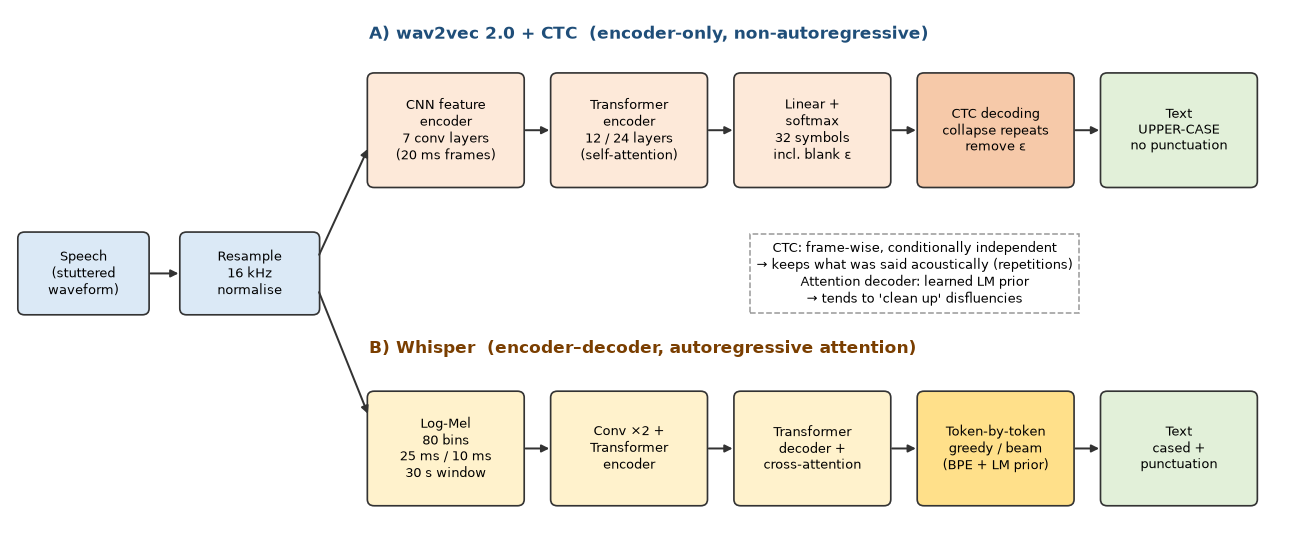

In [7]:
from matplotlib.patches import FancyBboxPatch
def box(ax, x, y_, w, h, txt, fc):
    ax.add_patch(FancyBboxPatch((x, y_), w, h, boxstyle="round,pad=0.02,rounding_size=0.08", fc=fc, ec="#333", lw=1.1))
    ax.text(x+w/2, y_+h/2, txt, ha="center", va="center", fontsize=8.6)
def arrow(ax, x1, y1, x2, y2): ax.annotate("", (x2, y2), (x1, y1), arrowprops=dict(arrowstyle="-|>", lw=1.3, color="#333"))

fig, ax = plt.subplots(figsize=(15, 6.2)); ax.set_xlim(0, 15); ax.set_ylim(0, 6.6); ax.axis("off")
box(ax, .1, 2.8, 1.5, 1, "Speech\n(stuttered\nwaveform)", "#dbe9f6"); arrow(ax, 1.6, 3.3, 2.0, 3.3)
box(ax, 2.0, 2.8, 1.6, 1, "Resample\n16 kHz\nnormalise", "#dbe9f6")
ax.text(4.2, 6.25, "A) wav2vec 2.0 + CTC  (encoder-only, non-autoregressive)", fontsize=11, weight="bold", color="#1f4e79")
arrow(ax, 3.6, 3.5, 4.2, 4.9)
steps = [("CNN feature\nencoder\n7 conv layers\n(20 ms frames)", "#fde9d9"), ("Transformer\nencoder\n12 / 24 layers\n(self-attention)", "#fde9d9"),
         ("Linear +\nsoftmax\n32 symbols\nincl. blank ε", "#fde9d9"), ("CTC decoding\ncollapse repeats\nremove ε", "#f6c9a9"), ("Text\nUPPER-CASE\nno punctuation", "#e2f0d9")]
for i, (s, c) in enumerate(steps):
    x = 4.2 + i*2.15; box(ax, x, 4.4, 1.8, 1.4, s, c)
    if i: arrow(ax, x-.35, 5.1, x, 5.1)
ax.text(4.2, 2.3, "B) Whisper  (encoder–decoder, autoregressive attention)", fontsize=11, weight="bold", color="#7a3e00")
arrow(ax, 3.6, 3.1, 4.2, 1.5)
steps = [("Log-Mel\n80 bins\n25 ms / 10 ms\n30 s window", "#fff2cc"), ("Conv ×2 +\nTransformer\nencoder", "#fff2cc"),
         ("Transformer\ndecoder +\ncross-attention", "#fff2cc"), ("Token-by-token\ngreedy / beam\n(BPE + LM prior)", "#ffe08a"), ("Text\ncased +\npunctuation", "#e2f0d9")]
for i, (s, c) in enumerate(steps):
    x = 4.2 + i*2.15; box(ax, x, .4, 1.8, 1.4, s, c)
    if i: arrow(ax, x-.35, 1.1, x, 1.1)
ax.text(10.6, 3.3, "CTC: frame-wise, conditionally independent\n→ keeps what was said acoustically (repetitions)\n"
        "Attention decoder: learned LM prior\n→ tends to 'clean up' disfluencies", fontsize=8.8, ha="center", va="center",
        bbox=dict(fc="white", ec="#999", ls="--"))
plt.savefig(f"{OUT}/04_asr_architecture.png", dpi=150, bbox_inches="tight"); plt.show()

## 5. ASR: transcribing the stuttered speech
We use two references:
* **Verbatim**: what was actually spoken, including the repetitions ("I'm I'm", "is it is it").
* **Intended (fluent)**: the message without the repetitions.

A CTC model that is faithful to the audio should score best against the *verbatim* reference. A model that "cleans up" the
speech should score best against the *intended* one.

In [8]:
REF_VERBATIM = ("excuse me please i really need your help could you point me to the central library "
    "i know i sound ridiculous right now every time i get this panicked my voice just completely locks up on me "
    "i'm i'm ten minutes late for my final exam and if i don't get to room three oh four in the next five minutes "
    "the grace period is over and the doors lock is it is it through the science atrium half the signs are missing and i "
    "oh brilliant just brilliant please you don't even have to speak just point left or right straight down the breezeway "
    "okay thank you you are a literal lifesaver")
REF_FLUENT = REF_VERBATIM.replace("i'm i'm", "i'm").replace("is it is it", "is it")
# same verbatim words with sentence punctuation (disfluencies left unpunctuated) - used to tell
# grammatical pauses (after , . ? !) from mid-phrase blocks
REF_VERBATIM_PUNCT = ("Excuse me, please, I really need your help. Could you point me to the central library? "
    "I know, I sound ridiculous right now. Every time I get this panicked, my voice just completely locks up on me. "
    "I'm I'm ten minutes late for my final exam, and if I don't get to room three oh four in the next five minutes, "
    "the grace period is over and the doors lock. Is it is it through the science atrium? Half the signs are missing and I "
    "oh, brilliant, just brilliant. Please, you don't even have to speak, just point. Left or right? Straight down the breezeway? "
    "Okay, thank you. You are a literal lifesaver.")

_ONES = "zero one two three four five six seven eight nine ten eleven twelve thirteen fourteen fifteen sixteen seventeen eighteen nineteen".split()
_TENS = "_ _ twenty thirty forty fifty sixty seventy eighty ninety".split()
def num2words(tok):
    n = int(tok)
    if len(tok) == 3: return " ".join("oh" if d == "0" else _ONES[int(d)] for d in tok)   # room numbers: 304 -> three oh four
    if n < 20: return _ONES[n]
    if n < 100: return _TENS[n//10] + ("" if n % 10 == 0 else " " + _ONES[n % 10])
    return tok
def normalize(s):
    s = s.lower().replace("’", "'")
    s = re.sub(r"\bo\.? ?k\b\.?", "okay", s)
    s = re.sub(r"\d+", lambda m: num2words(m.group()), s)
    s = re.sub(r"[^a-z' ]", " ", s)
    return re.sub(r"\s+", " ", s).strip()
assert normalize(REF_VERBATIM_PUNCT) == REF_VERBATIM
print(len(REF_VERBATIM.split()), "words (verbatim) |", len(REF_FLUENT.split()), "words (fluent)")

113 words (verbatim) | 110 words (fluent)


In [9]:
def n_params(m): return sum(p.numel() for p in m.parameters()) / 1e6
results, ctc_cache = {}, {}

for name in ["facebook/wav2vec2-base-960h", "facebook/wav2vec2-large-960h-lv60-self"]:
    proc = Wav2Vec2Processor.from_pretrained(name); model = Wav2Vec2ForCTC.from_pretrained(name).eval()
    t0 = time.time()
    with torch.no_grad():
        logits = model(proc(y, sampling_rate=SR, return_tensors="pt").input_values).logits[0]
    hyp = proc.batch_decode(logits.argmax(-1)[None])[0]
    results[name] = dict(arch="wav2vec2 + CTC (greedy)", params_M=n_params(model), rtf=(time.time()-t0)/dur, text=hyp)
    ctc_cache[name] = (proc, model, logits)

for name in ["openai/whisper-base", "openai/whisper-small"]:
    proc = WhisperProcessor.from_pretrained(name); model = WhisperForConditionalGeneration.from_pretrained(name).eval()
    feats = proc(y, sampling_rate=SR, return_tensors="pt", truncation=False, padding="longest",
                 return_attention_mask=True)          # long-form (>30 s) sequential decoding
    t0 = time.time()
    with torch.no_grad():
        ids = model.generate(feats.input_features, attention_mask=feats.attention_mask, language="en",
                             task="transcribe", return_timestamps=True, num_beams=1)
    hyp = proc.batch_decode(ids, skip_special_tokens=True)[0].strip()
    results[name] = dict(arch="Whisper enc-dec attention", params_M=n_params(model), rtf=(time.time()-t0)/dur, text=hyp)

for k, v in results.items(): print(f"\n=== {k}  ({v['params_M']:.0f} M params, RTF {v['rtf']:.2f})\n{v['text']}")

Loading weights: 100%|██████████| 479/479 [00:00<00:00, 508.98it/s]



=== facebook/wav2vec2-base-960h  (94 M params, RTF 0.17)
EXCUSE ME PLEASE I REALLY NEED YOUR HELP COULD YOU POINT ME TO THE CENTRAL LIBRARY I KNOW I SOUND RIDICULOUS RIGHT NOW EVERY TIME I GET THIS PANIC MY VOICE JUST COMPLETELY LOCKS UP ON ME I'M I'M TEN MINUTES LATE FOR MY FINAL EXAMINE AND IF I DON'T GET TO ROOM THREE OR FOUR IN THE NEXT FIVE MINUTES THE GREACE PERIOD IS OVER AND THE DOORS LOCK IS IT IS IT THROUGH THE SCINS ATRIUM HALF THE SCIGNS ARE MISSING AND I OH BRILLIANT JUST BRILLIANT PLEASE YOU DON'T EVEN HAVE TO SPEAK JUST POINT LEFT A RIGHT STRAIGHT DOWN THE RACEWAY THANK YOU YOU ARE A LITERAL LIFE SAVOR

=== facebook/wav2vec2-large-960h-lv60-self  (315 M params, RTF 0.47)
EXCUSE ME PLEASE I REALLY NEED YOUR HELP COULD YOU POINT ME TO THE CENTRAL LIBRARY I KNOW I SOUND RIDICULOUS RIGHT NOW EVERY TIME I GET THIS PANICD MY VOICE JUST IT COMPLETELY LOCKS UP ON ME I'M I'M TEN MINUTES LATE FOR MY FINAL EXAM AND IF I DON'T GET TO ROOM THREE O FOUR IN THE NEXT FIVE MINUTES THE G

## 6. CTC (Connectionist Temporal Classification)

**Problem.** The encoder outputs $T$ frames (here one per 20 ms, so about 2 300 for 46 s), but the transcript has only $U \ll T$
characters, and we don't know which frame belongs to which character. CTC trains *without* a frame-level alignment.

**Idea.**
1. Add a special **blank** symbol ε. At each frame the network outputs a softmax over $\{ε, A, …, Z, ', |\}$.
2. A frame-level path $\pi$ (one symbol per frame) maps to a label sequence through the collapse function $\mathcal{B}$:
   **(a) merge consecutive repeated symbols, then (b) delete blanks.**
   E.g. `__II_''M|||___II''M_` → `I'M|I'M`. A blank *between* two identical letters is what allows real double letters ("LL" in *brilliant*).
3. The probability of a transcript $y$ is the **sum over all paths** that collapse to it:
   $$P(y\mid x)=\sum_{\pi\in\mathcal{B}^{-1}(y)}\prod_{t=1}^{T} p_t(\pi_t)$$
   This sum is computed efficiently with the **forward–backward** dynamic program over the extended label sequence
   $ε\,y_1\,ε\,y_2\,…\,ε$ (length $2U+1$), at a cost of $O(T\cdot U)$.
4. **Loss** $= -\log P(y\mid x)$. **Decoding**: greedy (argmax per frame, then $\mathcal{B}$) or beam search, optionally with an LM.

**Why CTC matters for stuttering.** CTC assumes frames are *conditionally independent* and has no built-in language model.
It therefore transcribes what is acoustically present: repetitions survive, and long blocks become long runs of ε.
A sound repetition that never forms a full word ("p-p-") often gets absorbed into blanks.

In [10]:
proc, model, logits = ctc_cache["facebook/wav2vec2-base-960h"]
probs = logits.softmax(-1).numpy(); ids = probs.argmax(-1)
vocab = {v: k for k, v in proc.tokenizer.get_vocab().items()}; BLANK = proc.tokenizer.pad_token_id
FR = 320 / SR                                              # wav2vec2 CNN stride = 320 samples = 20 ms
print(f"T = {len(ids)} frames for {dur:.1f} s  ->  {FR*1000:.1f} ms/frame;  blank id = {BLANK} ('{vocab[BLANK]}')")
print(f"Frames whose argmax is blank: {(ids==BLANK).mean():.0%}")

# collapse rule step by step on the disfluent window 15.6 s – 20.2 s ("I'm ... I'm ten")
W0, W1 = 15.6, 20.2
a, b = int(W0/FR), int(W1/FR)
raw = "".join("_" if i == BLANK else vocab[i] for i in ids[a:b])
merged = [c for j, c in enumerate(raw) if j == 0 or c != raw[j-1]]
print("\n1) raw frame argmax  :", raw)
print("2) merge repeats     :", "".join(merged))
print("3) drop blanks (_)   :", "".join(c for c in merged if c != "_").replace("|", " "))

T = 2301 frames for 46.0 s  ->  20.0 ms/frame;  blank id = 0 ('<pad>')
Frames whose argmax is blank: 64%

1) raw frame argmax  : ________LL__OCC_K_SS||__UP_||__ON_||M__E_|||__________________________________________________________________I__'M_||______________________________________________________________________________________I_'M__||_T____ENN____||||_
2) merge repeats     : _L_OC_K_S|_UP_|_ON_|M_E_|_I_'M_|_I_'M_|_T_EN_|_
3) drop blanks (_)   : LOCKS UP ON ME I'M I'M TEN 


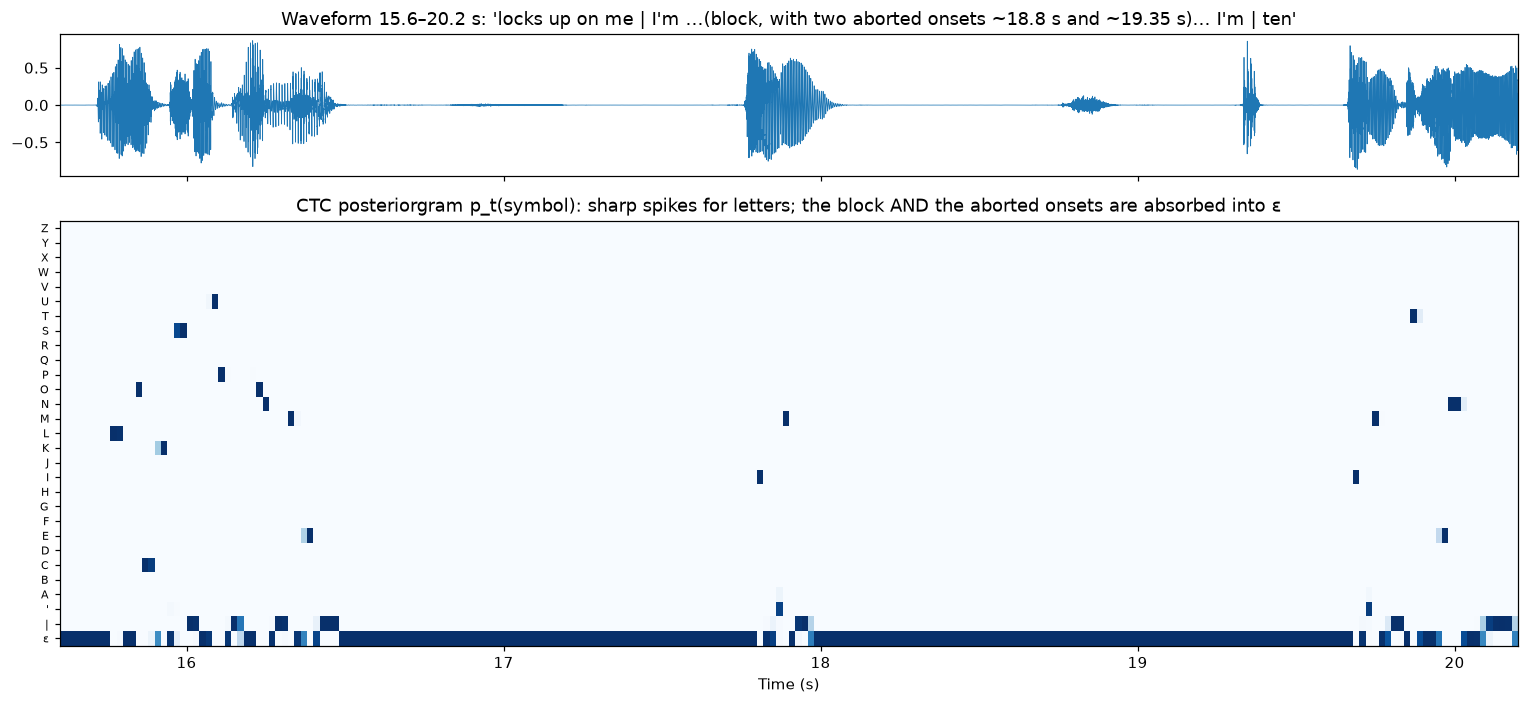

In [11]:
# Posteriorgram for the same window: which symbol is likely at each frame
letters = list("|'ABCDEFGHIJKLMNOPQRSTUVWXYZ")
show = [BLANK] + [proc.tokenizer.convert_tokens_to_ids(c) for c in letters]
fig, axs = plt.subplots(2, 1, figsize=(14, 6.5), sharex=True, gridspec_kw={"height_ratios": [1, 3]})
axs[0].plot(t[int(W0*SR):int(W1*SR)], y[int(W0*SR):int(W1*SR)], lw=.5)
axs[0].set_title(f"Waveform {W0}–{W1} s: 'locks up on me | I'm ...(block, with two aborted onsets ~18.8 s and ~19.35 s)... I'm | ten'")
axs[1].imshow(probs[a:b, show].T, aspect="auto", origin="lower", cmap="Blues",
              extent=[a*FR, b*FR, -.5, len(show)-.5], interpolation="nearest")
axs[1].set_yticks(range(len(show))); axs[1].set_yticklabels(["ε"] + letters, fontsize=7)
axs[1].set_xlabel("Time (s)"); axs[1].set_title("CTC posteriorgram p_t(symbol): sharp spikes for letters; the block AND the aborted onsets are absorbed into ε")
plt.tight_layout(); plt.savefig(f"{OUT}/05_ctc_posteriorgram.png", dpi=150); plt.show()

In [12]:
# CTC loss (= -log P(y|x), summed over ALL alignments by the forward algorithm) for the two references
log_probs = logits.log_softmax(-1)[:, None, :]          # (T, N=1, C)
def ctc_nll(text):
    tgt = torch.tensor(proc.tokenizer(text.upper().replace(" ", "|")).input_ids)
    return torch.nn.functional.ctc_loss(log_probs, tgt[None], torch.tensor([log_probs.shape[0]]), torch.tensor([len(tgt)]),
                                        blank=BLANK, reduction="sum").item(), len(tgt)
ctc_rows = []
for lab, ref in [("verbatim (with repetitions)", REF_VERBATIM), ("intended (fluent)", REF_FLUENT),
                 ("wav2vec2-base greedy output", results["facebook/wav2vec2-base-960h"]["text"].lower())]:
    nll, U = ctc_nll(ref); ctc_rows.append((lab, U, round(nll, 1), round(nll/U, 3)))
ctc_df = pd.DataFrame(ctc_rows, columns=["transcript", "labels U", "-log P(y|x)", "per label"])
display(ctc_df); ctc_df.to_csv(f"{OUT}/ctc_loss.csv", index=False)
print("-> lower loss = the acoustic model finds this transcript more probable")

,transcript,labels U,-log P(y|x),per label
0,verbatim (with repetitions),574,86.4,0.151
1,intended (fluent),564,156.3,0.277
2,wav2vec2-base greedy output,567,31.5,0.056


-> lower loss = the acoustic model finds this transcript more probable


Words that come right after a silent block (gap >= 0.6 s):


,word,start_s,end_s,gap_before_s
3,I,2.10,2.12,0.60
8,COULD,4.38,4.52,1.08
10,POINT,5.98,6.14,1.34
16,I,8.56,8.58,1.12
23,EVERY,11.40,11.56,0.80
32,COMPLETELY,14.52,14.92,0.92
33,LOCKS,15.76,16.00,0.84
37,I'M,17.80,17.90,1.40
38,I'M,19.68,19.76,1.78
40,MINUTES,20.72,21.00,0.70


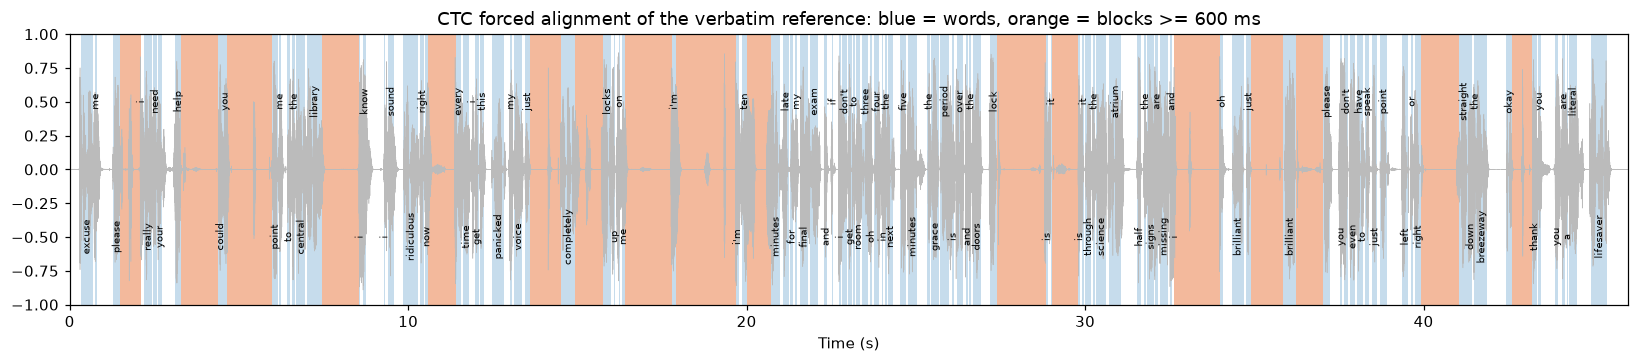

In [13]:
# Viterbi forced alignment: the single best CTC path for the verbatim reference -> word timestamps
def ctc_force_align(lp, tokens, blank):
    T, S = lp.shape[0], 2*len(tokens)+1
    ext = np.array([blank if s % 2 == 0 else tokens[s//2] for s in range(S)])
    skip = np.zeros(S, bool)
    for s in range(2, S): skip[s] = ext[s] != blank and ext[s] != ext[s-2]
    D = np.full((T, S), -np.inf); bp = np.zeros((T, S), int)
    D[0, 0], D[0, 1] = lp[0, ext[0]], lp[0, ext[1]]
    for t_ in range(1, T):
        stay = D[t_-1]
        one = np.concatenate([[-np.inf], D[t_-1, :-1]])
        two = np.where(skip, np.concatenate([[-np.inf, -np.inf], D[t_-1, :-2]]), -np.inf)
        stack = np.vstack([stay, one, two]); arg = stack.argmax(0)
        D[t_] = stack.max(0) + lp[t_, ext]; bp[t_] = np.arange(S) - arg
    s = S-1 if D[-1, S-1] > D[-1, S-2] else S-2; path = []
    for t_ in range(T-1, -1, -1): path.append((t_, s)); s = bp[t_, s]
    return path[::-1], ext

DELIM = proc.tokenizer.convert_tokens_to_ids("|")
def align_words(logits_, text):
    # forced-align `text` to the CTC output; each non-blank state (odd s) = one character, words split at '|'
    path, ext = ctc_force_align(logits_.log_softmax(-1).numpy(), proc.tokenizer(text.upper().replace(" ", "|")).input_ids, BLANK)
    spans = {}
    for t_, s in path:
        if s % 2: spans.setdefault(s, [t_, t_])[1] = t_
    words, cur = [], ""
    for s in range(1, len(ext), 2):
        if ext[s] == DELIM:
            if cur: words.append((cur, ws, we)); cur = ""
            continue
        if not cur: ws = spans[s][0] * FR
        cur += vocab[ext[s]]; we = (spans[s][1] + 1) * FR
    if cur: words.append((cur, ws, we))
    df = pd.DataFrame(words, columns=["word", "start_s", "end_s"]).round(2)
    df["gap_before_s"] = (df.start_s - df.end_s.shift(1)).fillna(0).round(2)
    return df

wdf = align_words(logits, REF_VERBATIM); words = list(wdf[["word", "start_s", "end_s"]].itertuples(index=False))
print("Words that come right after a silent block (gap >= 0.6 s):")
display(wdf[wdf.gap_before_s >= 0.6])
wdf.to_csv(f"{OUT}/word_alignment.csv", index=False)

fig, ax = plt.subplots(figsize=(15, 3.4))
ax.plot(t, y, lw=.35, color="#bbb")
for i, (w, s0, e0) in enumerate(words):
    ax.axvspan(s0, e0, color="#1f77b4", alpha=.25, lw=0)
    ax.text((s0+e0)/2, .5 if i % 2 else -.5, w.lower(), ha="center", va="center", fontsize=6.3, rotation=90)
for _, r in wdf[wdf.gap_before_s >= 0.6].iterrows():
    ax.axvspan(r.start_s - r.gap_before_s, r.start_s, color="#e8743b", alpha=.5, lw=0)
ax.set(xlim=(0, dur), ylim=(-1, 1), xlabel="Time (s)",
       title="CTC forced alignment of the verbatim reference: blue = words, orange = blocks >= 600 ms")
plt.tight_layout(); plt.savefig(f"{OUT}/06_ctc_forced_alignment.png", dpi=150); plt.show()

## 7. WER calculation
$$\text{WER}=\frac{S+D+I}{N}$$
$S$ = substitutions, $D$ = deletions, $I$ = insertions, $N$ = number of reference words. These come from the minimum edit
(Levenshtein) distance between the reference and the hypothesis at the **word** level. CER is the same formula on characters.

Below, the DP is written out by hand with a backtrace that labels every error. The result is then checked against `jiwer`.

In [14]:
def wer_dp(ref, hyp):
    r, h = ref.split(), hyp.split(); R, H = len(r), len(h)
    D = np.zeros((R+1, H+1), int); D[:, 0] = range(R+1); D[0, :] = range(H+1)
    for i in range(1, R+1):
        for j in range(1, H+1):
            D[i, j] = min(D[i-1, j-1] + (r[i-1] != h[j-1]), D[i-1, j] + 1, D[i, j-1] + 1)
    i, j, ops = R, H, []                                  # backtrace
    while i or j:
        if i and j and D[i, j] == D[i-1, j-1] + (r[i-1] != h[j-1]):
            ops.append(("OK" if r[i-1] == h[j-1] else "S", r[i-1], h[j-1])); i, j = i-1, j-1
        elif i and D[i, j] == D[i-1, j] + 1: ops.append(("D", r[i-1], "***")); i -= 1
        else: ops.append(("I", "***", h[j-1])); j -= 1
    ops = ops[::-1]; c = {k: sum(o[0] == k for o in ops) for k in ("S", "D", "I")}
    return dict(N=R, **c, WER=(c["S"]+c["D"]+c["I"])/R, ops=ops)

# worked example for wav2vec2-base vs the verbatim reference
hyp = normalize(results["facebook/wav2vec2-base-960h"]["text"]); ref = normalize(REF_VERBATIM)
res = wer_dp(ref, hyp)
print(f"N={res['N']}  S={res['S']}  D={res['D']}  I={res['I']}  ->  WER = ({res['S']}+{res['D']}+{res['I']})/{res['N']} = {res['WER']:.2%}")
print("jiwer check:", f"{jiwer.wer(ref, hyp):.2%}")
print("\nError list:")
for op, r_, h_ in res["ops"]:
    if op != "OK": print(f"  {op}:  ref='{r_}'  hyp='{h_}'")

N=113  S=9  D=1  I=1  ->  WER = (9+1+1)/113 = 9.73%
jiwer check: 9.73%

Error list:
  S:  ref='panicked'  hyp='panic'
  S:  ref='exam'  hyp='examine'
  S:  ref='oh'  hyp='or'
  S:  ref='grace'  hyp='greace'
  S:  ref='science'  hyp='scins'
  S:  ref='signs'  hyp='scigns'
  S:  ref='or'  hyp='a'
  D:  ref='breezeway'  hyp='***'
  S:  ref='okay'  hyp='raceway'
  I:  ref='***'  hyp='life'
  S:  ref='lifesaver'  hyp='savor'


## 8. ASR comparison table
**Repetitions kept** counts how many of the two spoken repetitions ("i'm i'm" and "is it is it") appear in the output.
**RTF** is the real-time factor: processing time ÷ audio duration, measured on CPU. Below 1 means faster than real time.

Model,Architecture,Params (M),WER verbatim,S/D/I (verbatim),WER fluent,S/D/I (fluent),CER verbatim,Repetitions kept (of 2),Punctuation/case,RTF (CPU)
wav2vec2-base-960h,wav2vec2 + CTC (greedy),94,9.7%,9/1/1,12.7%,9/1/4,4.4%,2,no,0.170000
wav2vec2-large-960h-lv60-self,wav2vec2 + CTC (greedy),315,6.2%,5/0/2,9.1%,5/0/5,2.4%,2,no,0.470000
whisper-base,Whisper enc-dec attention,73,2.7%,1/2/0,1.8%,1/0/1,1.6%,1,yes,0.140000
whisper-small,Whisper enc-dec attention,242,3.5%,1/3/0,0.9%,1/0/0,2.4%,0,yes,0.330000


                        Model              Architecture  Params (M)  WER verbatim S/D/I (verbatim)  WER fluent S/D/I (fluent)  CER verbatim  Repetitions kept (of 2) Punctuation/case  RTF (CPU)
           wav2vec2-base-960h   wav2vec2 + CTC (greedy)          94      0.097345            9/1/1    0.127273          9/1/4      0.043554                        2               no       0.17
wav2vec2-large-960h-lv60-self   wav2vec2 + CTC (greedy)         315      0.061947            5/0/2    0.090909          5/0/5      0.024390                        2               no       0.47
                 whisper-base Whisper enc-dec attention          73      0.026549            1/2/0    0.018182          1/0/1      0.015679                        1              yes       0.14
                whisper-small Whisper enc-dec attention         242      0.035398            1/3/0    0.009091          1/0/0      0.024390                        0              yes       0.33


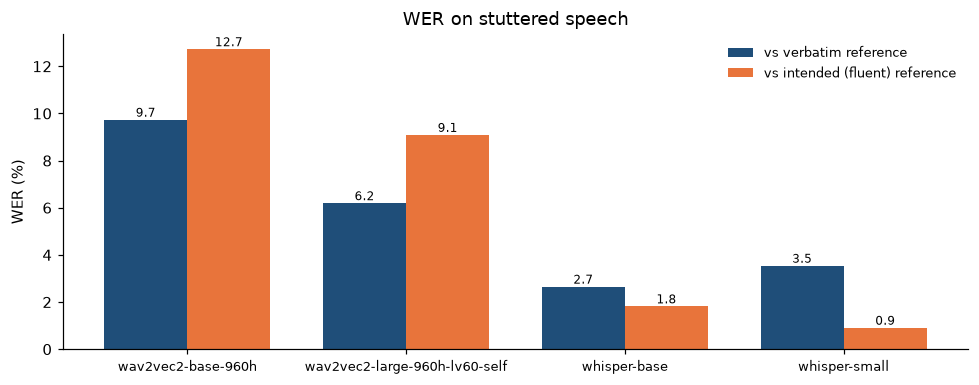

In [15]:
rows = []
for name, v in results.items():
    h = normalize(v["text"]); rv = wer_dp(normalize(REF_VERBATIM), h); rf = wer_dp(normalize(REF_FLUENT), h)
    rows.append({"Model": name.split("/")[1], "Architecture": v["arch"], "Params (M)": round(v["params_M"]),
                 "WER verbatim": rv["WER"], "S/D/I (verbatim)": f"{rv['S']}/{rv['D']}/{rv['I']}",
                 "WER fluent": rf["WER"], "S/D/I (fluent)": f"{rf['S']}/{rf['D']}/{rf['I']}",
                 "CER verbatim": jiwer.cer(normalize(REF_VERBATIM), h),
                 "Repetitions kept (of 2)": int("i'm i'm" in h) + int("is it is it" in h),
                 "Punctuation/case": "yes" if v["arch"].startswith("Whisper") else "no", "RTF (CPU)": round(v["rtf"], 2)})
cmp_df = pd.DataFrame(rows)
cmp_df.to_csv(f"{OUT}/asr_comparison.csv", index=False)
display(cmp_df.style.format({"WER verbatim": "{:.1%}", "WER fluent": "{:.1%}", "CER verbatim": "{:.1%}"}).hide(axis="index"))
print(cmp_df.to_string(index=False))
pd.DataFrame([(k, v["text"]) for k, v in results.items()], columns=["model", "transcript"]).to_csv(f"{OUT}/transcripts.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 3.6)); xi = np.arange(len(cmp_df)); w = .38
b1 = ax.bar(xi-w/2, cmp_df["WER verbatim"]*100, w, label="vs verbatim reference", color="#1f4e79")
b2 = ax.bar(xi+w/2, cmp_df["WER fluent"]*100, w, label="vs intended (fluent) reference", color="#e8743b")
ax.bar_label(b1, fmt="%.1f", fontsize=8); ax.bar_label(b2, fmt="%.1f", fontsize=8)
ax.set_xticks(xi); ax.set_xticklabels(cmp_df.Model, fontsize=8.5); ax.set_ylabel("WER (%)"); ax.legend(frameon=False, fontsize=8.5)
ax.set_title("WER on stuttered speech"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(f"{OUT}/07_wer_comparison.png", dpi=150); plt.show()

## 9. Text → TTS → Speech
The ASR text is turned back into speech. The best-scoring transcript is fed to an offline TTS engine
(`pyttsx3` → Windows SAPI5. On Colab the code falls back to `gTTS`). Then:
* we compare the original and synthetic speech (waveform + log-Mel). The TTS speech is **fluent**: no blocks, no repetitions.
* **Round trip**: the TTS audio goes back through wav2vec2-CTC, and we compute its WER against the text it was made from. This
  shows how intelligible the synthetic speech is.

In [17]:
best = cmp_df.sort_values("WER fluent").iloc[0]["Model"]
tts_text = next(v["text"] for k, v in results.items() if k.endswith(best))
print("TTS input (from", best, "):\n", tts_text)
TTS_WAV = f"{OUT}/tts_output.wav"
try:
    import pyttsx3
    eng = pyttsx3.init(); eng.setProperty("rate", 165)
    voices = eng.getProperty("voices"); male = [v for v in voices if "david" in v.name.lower()]   # male voice
    voice = male[0] if male else voices[0]; eng.setProperty("voice", voice.id)
    eng.save_to_file(tts_text, TTS_WAV); eng.runAndWait(); engine_name = f"pyttsx3 / SAPI5 ({voice.name})"
except Exception as e:                                  # Colab / Linux fallback
    print("pyttsx3 unavailable:", e)
    from gtts import gTTS; TTS_WAV = f"{OUT}/tts_output.mp3"; gTTS(tts_text, lang="en", tld="co.uk").save(TTS_WAV); engine_name = "gTTS"
y_tts, _ = librosa.load(TTS_WAV, sr=SR)
print(f"Engine: {engine_name} | TTS duration {len(y_tts)/SR:.1f} s vs original {dur:.1f} s")
display(Audio(y_tts, rate=SR))

TTS input (from whisper-small ):
 Excuse me, please, I really need your help. Could you point me to the central library? I know, I sound ridiculous right now. Every time I get this panicked, my voice just completely locks up on me. I'm ten minutes late for my final exam, and if I don't get to room 304 in the next five minutes, the grace period is over and the doors lock. Is it through the signs, Atrium? Half the signs are missing and I... Oh, brilliant, just brilliant. Please, you don't even have to speak, just point. Left or right? Straight down the breezeway? Okay, thank you. You are a literal lifesaver.
pyttsx3 unavailable: No module named 'pywintypes'
Engine: gTTS | TTS duration 49.5 s vs original 46.0 s


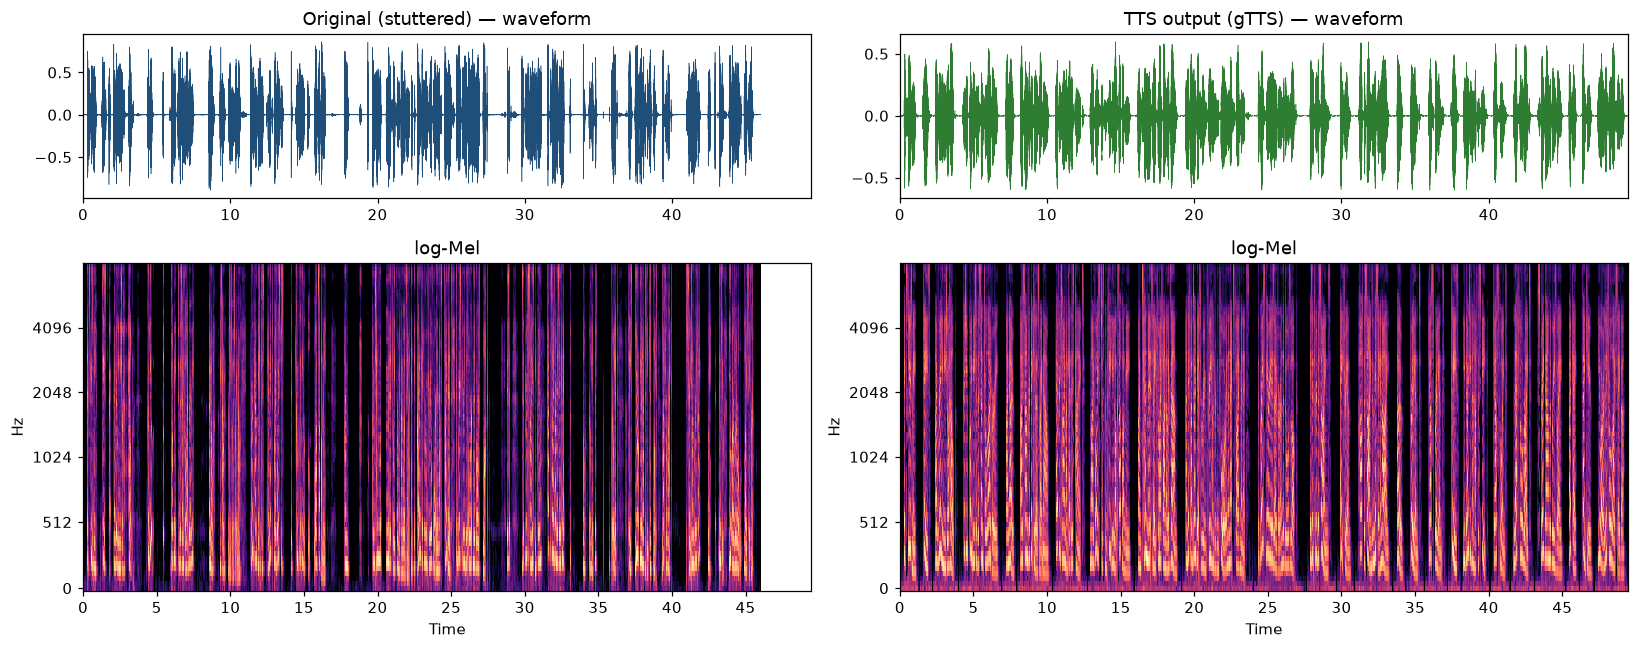

,Original (stuttered),TTS output
Duration (s),46.0,49.5
Words / min,147,133
Silence ratio,38%,20%
Pauses >=600 ms at punctuation (grammatical),9,21
Pauses >=600 ms mid-phrase (BLOCKS),8,0
Word repetitions,2,0


Mid-phrase blocks in the ORIGINAL (word that follows the block):


,word,start_s,gap_before_s
10,POINT,5.98,1.34
32,COMPLETELY,14.52,0.92
33,LOCKS,15.76,0.84
38,I'M,19.68,1.78
40,MINUTES,20.72,0.70
72,IS,29.80,0.78
85,OH,34.00,1.36
88,BRILLIANT,35.86,0.96


Mid-phrase blocks in the TTS output: none
Round-trip ASR on TTS audio:
 EXCUSE ME PLEASE I REALLY NEED YOUR HELP COULD YOU POINT ME TO THE CENTRAL LIBRARY I KNOW I SOUND RIDICULOUS RIGHT NOW EVERY TIME I GET THIS PANICE MY VOICE JUST COMPLETELY LOCKS UP ON ME I'M TEN MINUTES LATE FOR MY FINAL EXAM AND IF I DON'T GET TO ROOM THREE HUNDRED AND FOUR IN THE NEXT FIVE MINUTES THE GRACE PERIOD IS OVER AND THE DOOR'S LOCK IS IT THROUGH THE SIGNS ATRIANT HALF THE SIGNS AE MISSING AND I OH BRILLIANT JUST BRILLIANT PLEASE YOU DON'T EVEN HAVE TO SPEAK JUST POINT LEFT ALL RIGHT STRAIGHT DOWN THE BREEZE WAY OKE THANK YOU YOU ARE A LITERAL LIFE SAVOR

Round-trip WER (TTS text -> speech -> wav2vec2): 10.9%   (S=9 D=0 I=3, N=110)
  S:  ref='panicked'  hyp='panice'
  I:  ref='***'  hyp='hundred'
  S:  ref='oh'  hyp='and'
  S:  ref='doors'  hyp='door's'
  S:  ref='atrium'  hyp='atriant'
  S:  ref='are'  hyp='ae'
  S:  ref='or'  hyp='all'
  I:  ref='***'  hyp='breeze'
  S:  ref='breezeway'  hyp='way'
  S

In [18]:
iv_t = librosa.effects.split(y_tts, top_db=35, frame_length=1024, hop_length=256)
gaps_t = [(iv_t[i+1][0]-iv_t[i][1])/SR for i in range(len(iv_t)-1)]
lm_t = librosa.power_to_db(librosa.feature.melspectrogram(y=y_tts, sr=SR, n_fft=N_FFT, win_length=WIN, hop_length=HOP,
                                                          n_mels=N_MELS, window="hamming"), ref=np.max)
tmax = max(dur, len(y_tts)/SR)
fig, axs = plt.subplots(2, 2, figsize=(15, 6), gridspec_kw={"height_ratios": [1, 2]})
for col, (sig, lm, title) in enumerate([(y, logmel, "Original (stuttered)"), (y_tts, lm_t, f"TTS output ({engine_name.split(' (')[0]})")]):
    axs[0, col].plot(np.arange(len(sig))/SR, sig, lw=.35, color="#1f4e79" if col == 0 else "#2e7d32")
    axs[0, col].set(title=title + " — waveform", xlim=(0, tmax))
    librosa.display.specshow(lm, sr=SR, hop_length=HOP, x_axis="time", y_axis="mel", ax=axs[1, col], cmap="magma")
    axs[1, col].set(title="log-Mel", xlim=(0, tmax))
plt.tight_layout(); plt.savefig(f"{OUT}/08_original_vs_tts.png", dpi=150); plt.show()

proc_b, model_b, _ = ctc_cache["facebook/wav2vec2-base-960h"]
with torch.no_grad():
    rt_hyp = proc_b.batch_decode(model_b(proc_b(y_tts, sampling_rate=SR, return_tensors="pt").input_values).logits.argmax(-1))[0]
rt = wer_dp(normalize(tts_text), normalize(rt_hyp))
tts_dur = len(y_tts) / SR

def pause_profile(sig, punct_text):
    # forced-align, then split long pauses into grammatical (after , . ? !) and mid-phrase (= disfluent block)
    with torch.no_grad(): lg = model_b(proc_b(sig, sampling_rate=SR, return_tensors="pt").input_values).logits[0]
    df = align_words(lg, normalize(punct_text))
    after_punct = []
    for tok in punct_text.split():
        n = len(normalize(tok).split())
        after_punct += [False] * (n - 1) + [bool(re.search(r"[.,?!]$", tok))] if n else []
    df["after_punct"] = [False] + after_punct[:len(df) - 1]
    long_ = df[df.gap_before_s >= 0.6]
    return df, int((long_.after_punct).sum()), int((~long_.after_punct).sum()), long_[~long_.after_punct]

orig_df, orig_gram, orig_mid, orig_mid_rows = pause_profile(y, REF_VERBATIM_PUNCT)
tts_df, tts_gram, tts_mid, tts_mid_rows = pause_profile(y_tts, tts_text)
tts_stats = pd.DataFrame({
    "Original (stuttered)": [round(dur, 1), round(len(normalize(REF_VERBATIM).split())/dur*60), f"{silence_ratio:.0%}",
                             orig_gram, orig_mid, 2],
    "TTS output": [round(tts_dur, 1), round(len(normalize(tts_text).split())/tts_dur*60),
                   f"{1 - sum(e-s for s, e in iv_t)/len(y_tts):.0%}", tts_gram, tts_mid,
                   int("i'm i'm" in normalize(tts_text)) + int("is it is it" in normalize(tts_text))]},
    index=["Duration (s)", "Words / min", "Silence ratio", "Pauses >=600 ms at punctuation (grammatical)",
           "Pauses >=600 ms mid-phrase (BLOCKS)", "Word repetitions"])
display(tts_stats); tts_stats.to_csv(f"{OUT}/tts_vs_original.csv")
print("Mid-phrase blocks in the ORIGINAL (word that follows the block):")
display(orig_mid_rows[["word", "start_s", "gap_before_s"]])
print("Mid-phrase blocks in the TTS output:", "none" if tts_mid == 0 else "")
if tts_mid: display(tts_mid_rows[["word", "start_s", "gap_before_s"]])
print("Round-trip ASR on TTS audio:\n", rt_hyp)
print(f"\nRound-trip WER (TTS text -> speech -> wav2vec2): {rt['WER']:.1%}   (S={rt['S']} D={rt['D']} I={rt['I']}, N={rt['N']})")
for op, r_, h_ in rt["ops"]:
    if op != "OK": print(f"  {op}:  ref='{r_}'  hyp='{h_}'")

## 10. Summary

In [19]:
print("Pauses/blocks:", len(pause_df), "pauses,", int((pause_df.dur_s >= .6).sum()), "blocks; silence ratio", f"{silence_ratio:.0%}")
display(cmp_df[["Model", "Architecture", "WER verbatim", "WER fluent", "Repetitions kept (of 2)"]]
        .style.format({"WER verbatim": "{:.1%}", "WER fluent": "{:.1%}"}).hide(axis="index"))
print(f"Round-trip TTS->ASR WER: {rt['WER']:.1%}")
print("Figures saved in ./outputs:", sorted(f for f in os.listdir(OUT) if f.endswith('.png')))

Pauses/blocks: 23 pauses, 10 blocks; silence ratio 38%


Model,Architecture,WER verbatim,WER fluent,Repetitions kept (of 2)
wav2vec2-base-960h,wav2vec2 + CTC (greedy),9.7%,12.7%,2
wav2vec2-large-960h-lv60-self,wav2vec2 + CTC (greedy),6.2%,9.1%,2
whisper-base,Whisper enc-dec attention,2.7%,1.8%,1
whisper-small,Whisper enc-dec attention,3.5%,0.9%,0


Round-trip TTS->ASR WER: 10.9%
Figures saved in ./outputs: ['01_waveform.png', '02_feature_steps.png', '03_logmel_spectrogram.png', '04_asr_architecture.png', '05_ctc_posteriorgram.png', '06_ctc_forced_alignment.png', '07_wer_comparison.png', '08_original_vs_tts.png']
